In [69]:
# Session分层与预测

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# 重新读取原始数据
file_path = "../data/raw/online_shoppers_intention.csv"

df = pd.read_csv(file_path)

print("数据维度：", df.shape)

df.head()

数据维度： (12330, 18)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [70]:
# 检查核心字段

print(df.shape)

print(df[
    [
        "ProductRelated",
        "ProductRelated_Duration",
        "BounceRates",
        "ExitRates",
        "PageValues",
        "Revenue"
    ]
].head())

print(df["Revenue"].value_counts())

(12330, 18)
   ProductRelated  ProductRelated_Duration  BounceRates  ExitRates  \
0               1                 0.000000         0.20       0.20   
1               2                64.000000         0.00       0.10   
2               1                 0.000000         0.20       0.20   
3               2                 2.666667         0.05       0.14   
4              10               627.500000         0.02       0.05   

   PageValues  Revenue  
0         0.0    False  
1         0.0    False  
2         0.0    False  
3         0.0    False  
4         0.0    False  
Revenue
False    10422
True      1908
Name: count, dtype: int64


In [71]:
# 使用 P75 定义高行为深度
p75 = df["ProductRelated"].quantile(0.75)

print("P75 =", p75)

df["high_activity"] = (
    df["ProductRelated"] >= p75
)

df[
    ["ProductRelated", "Revenue", "high_activity"]
].head()


P75 = 38.0


,ProductRelated,Revenue,high_activity
0,1,False,False
1,2,False,False
2,1,False,False
3,2,False,False
4,10,False,False


In [72]:
def segment_session(row):
    if row["high_activity"] and row["Revenue"]:
        return "High_Value"
    
    elif row["high_activity"] and not row["Revenue"]:
        return "High_Potential"
    
    elif not row["high_activity"] and row["Revenue"]:
        return "Low_Activity_Purchase"
    
    else:
        return "Low_Activity_NonPurchase"


df["session_segment"] = df.apply(
    segment_session,
    axis=1
)

df["session_segment"].value_counts()

session_segment
Low_Activity_NonPurchase    8046
High_Potential              2376
Low_Activity_Purchase       1178
High_Value                   730
Name: count, dtype: int64

In [73]:
#统计四类session
segment_summary = (
    df.groupby("session_segment")
    .agg(
        session_cnt=("Revenue", "size"),
        purchase_cnt=("Revenue", "sum"),
        avg_product_views=("ProductRelated", "mean"),
        avg_product_duration=("ProductRelated_Duration", "mean"),
        avg_bounce_rate=("BounceRates", "mean"),
        avg_exit_rate=("ExitRates", "mean"),
        avg_page_value=("PageValues", "mean")
    )
    .reset_index()
)

segment_summary

#再增加占比
segment_summary["session_share"] = (
    segment_summary["session_cnt"]
    / len(df)
    * 100
)

segment_summary

,session_segment,session_cnt,purchase_cnt,avg_product_views,avg_product_duration,avg_bounce_rate,avg_exit_rate,avg_page_value,session_share
0,High_Potential,2376,0,80.864478,2941.962073,0.007614,0.021814,4.182961,19.270073
1,High_Value,730,730,96.050685,3593.003422,0.004543,0.015758,20.525807,5.920519
2,Low_Activity_NonPurchase,8046,0,13.314691,517.190040,0.030545,0.054927,1.324277,65.255474
3,Low_Activity_Purchase,1178,1178,18.563667,812.322111,0.005473,0.021909,31.440460,9.553933


In [74]:
high_potential_p75 = df[
    (df["ProductRelated"] >= p75)
    & (df["Revenue"] == False)
].copy()

high_potential_p75["VisitorType"].value_counts(
    normalize=True
) * 100



VisitorType
Returning_Visitor    95.117845
New_Visitor           4.840067
Other                 0.042088
Name: proportion, dtype: float64

In [75]:
hp_visitor = (
    high_potential_p75
    .groupby("VisitorType")
    .size()
    .reset_index(name="session_cnt")
)

hp_visitor

,VisitorType,session_cnt
0,New_Visitor,115
1,Other,1
2,Returning_Visitor,2260


In [76]:
bins = [-1, 5, 10, 20, 50, np.inf]

labels = [
    "0-5",
    "6-10",
    "11-20",
    "21-50",
    "50+"
]

df["product_view_group"] = pd.cut(
    df["ProductRelated"],
    bins=bins,
    labels=labels
)

visitor_depth = (
    df.groupby(
        ["VisitorType", "product_view_group"],
        observed=False
    )
    .agg(
        session_cnt=("Revenue", "size"),
        purchase_cnt=("Revenue", "sum")
    )
    .reset_index()
)

visitor_depth["conversion_rate"] = (
    visitor_depth["purchase_cnt"]
    / visitor_depth["session_cnt"]
    * 100
)

visitor_depth

,VisitorType,product_view_group,session_cnt,purchase_cnt,conversion_rate
0,New_Visitor,0-5,328,40,12.195122
1,New_Visitor,6-10,369,73,19.783198
2,New_Visitor,11-20,489,131,26.789366
3,New_Visitor,21-50,424,149,35.141509
4,New_Visitor,50+,84,29,34.523810
5,Other,0-5,43,3,6.976744
6,Other,6-10,15,1,6.666667
7,Other,11-20,13,4,30.769231
8,Other,21-50,12,7,58.333333
9,Other,50+,2,1,50.000000


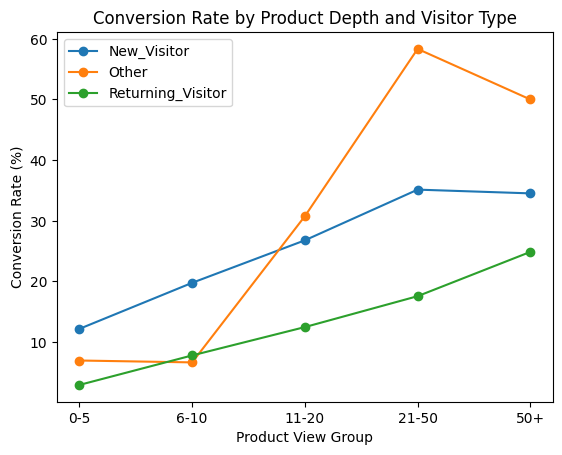

In [77]:
for visitor_type in visitor_depth["VisitorType"].unique():
    
    temp = visitor_depth[
        visitor_depth["VisitorType"] == visitor_type
    ]
    
    plt.plot(
        temp["product_view_group"].astype(str),
        temp["conversion_rate"],
        marker="o",
        label=visitor_type
    )

plt.xlabel("Product View Group")
plt.ylabel("Conversion Rate (%)")
plt.title(
    "Conversion Rate by Product Depth and Visitor Type"
)
plt.legend()

plt.savefig(
    "../images/conversion_rate_by_product_depth_and_visitor_type.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [78]:
high_potential = df[
    (df["ProductRelated"] >= 30)
    & (df["Revenue"] == False)
].copy()


hp_month = (
    high_potential_p75
    .groupby("Month")
    .size()
    .reset_index(name="session_cnt")
)

hp_month.sort_values(
    "session_cnt",
    ascending=False
)

,Month,session_cnt
7,Nov,690
6,May,626
1,Dec,343
5,Mar,212
0,Aug,118
8,Oct,111
3,Jul,97
9,Sep,94
4,June,77
2,Feb,8


In [79]:
non_purchase = df[
    df["Revenue"] == False
].copy()

non_purchase_month = (
    non_purchase
    .groupby("Month")
    .size()
    .reset_index(name="non_purchase_cnt")
)

hp_month_rate = hp_month.merge(
    non_purchase_month,
    on="Month",
    how="left"
)

hp_month_rate["high_potential_rate"] = (
    hp_month_rate["session_cnt"]
    / hp_month_rate["non_purchase_cnt"]
    * 100
)

hp_month_rate.sort_values(
    "high_potential_rate",
    ascending=False
)

,Month,session_cnt,non_purchase_cnt,high_potential_rate
0,Aug,118,357,33.053221
7,Nov,690,2238,30.831099
4,June,77,259,29.729730
3,Jul,97,366,26.502732
9,Sep,94,362,25.966851
8,Oct,111,434,25.576037
1,Dec,343,1511,22.700199
6,May,626,2999,20.873625
5,Mar,212,1715,12.361516
2,Feb,8,181,4.419890


In [80]:
#渠道*高潜率
hp_traffic = (
    high_potential_p75
    .groupby("TrafficType")
    .size()
    .reset_index(name="high_potential_cnt")
)

non_purchase_traffic = (
    non_purchase
    .groupby("TrafficType")
    .size()
    .reset_index(name="non_purchase_cnt")
)

traffic_hp = hp_traffic.merge(
    non_purchase_traffic,
    on="TrafficType",
    how="left"
)

traffic_hp["high_potential_rate"] = (
    traffic_hp["high_potential_cnt"]
    / traffic_hp["non_purchase_cnt"]
    * 100
)

traffic_hp.sort_values(
    "high_potential_rate",
    ascending=False
)


,TrafficType,high_potential_cnt,non_purchase_cnt,high_potential_rate
1,2,852,3066,27.788650
15,19,4,16,25.000000
5,6,96,391,24.552430
11,13,168,695,24.172662
0,1,512,2189,23.389676
3,4,210,904,23.230088
6,7,6,28,21.428571
9,10,73,360,20.277778
2,3,345,1872,18.429487
12,14,2,11,18.181818


In [81]:
#机器学习模型第一版
features = [
    "Administrative",
    "Administrative_Duration",
    "Informational",
    "Informational_Duration",
    "ProductRelated",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates",
    "PageValues",
    "SpecialDay"
]

target = "Revenue"

In [82]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [83]:
import sklearn
print(sklearn.__version__)

1.3.2


In [84]:
#划分训练集和测试集

from sklearn.model_selection import train_test_split

X = df[features]

y = df["Revenue"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [85]:
#第一个模型：Logistic Regression

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "model",
        LogisticRegression(
            max_iter=1000,
            class_weight="balanced"
        )
    )
])

logistic_model.fit(
    X_train,
    y_train
)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [86]:
#模型评估
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

y_pred = logistic_model.predict(X_test)

y_prob = logistic_model.predict_proba(
    X_test
)[:, 1]

print(
    classification_report(
        y_test,
        y_pred
    )
)

print(
    confusion_matrix(
        y_test,
        y_pred
    )
)

print(
    "ROC-AUC:",
    roc_auc_score(
        y_test,
        y_prob
    )
)

              precision    recall  f1-score   support

           0       0.94      0.89      0.91      2084
           1       0.54      0.70      0.61       382

    accuracy                           0.86      2466
   macro avg       0.74      0.79      0.76      2466
weighted avg       0.88      0.86      0.87      2466

[[1853  231]
 [ 116  266]]
ROC-AUC: 0.8647398277577354


In [87]:
#做一个“去掉PageValues”的模型(A/B实验)
#Model A 包含 PageValues，Model B 不包含 PageValues
#Model A 保留 PageValues：

features_A = features

X_A = df[features_A]

In [88]:
# Model B 删除 PageValues：
features_B = [
    col
    for col in features
    if col != "PageValues"
]

X_B = df[features_B]

In [89]:
print("Model A 特征：")
print(features_A)

print("\nModel B 特征：")
print(features_B)

Model A 特征：
['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay']

Model B 特征：
['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'SpecialDay']


In [90]:
#关键——保证 A/B 用完全相同的数据划分
#比较严谨的方法是先划分行索引，再让 A 和 B 使用同样的行。

from sklearn.model_selection import train_test_split

train_idx, test_idx = train_test_split(
    df.index,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [91]:
# 保证了Model A 和 Model B 预测的是完全相同的测试用户
X_A_train = X_A.loc[train_idx]
X_A_test = X_A.loc[test_idx]

X_B_train = X_B.loc[train_idx]
X_B_test = X_B.loc[test_idx]

y_train = y.loc[train_idx]
y_test = y.loc[test_idx]

In [92]:
# 训练model A
from sklearn.linear_model import LogisticRegression

model_A = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model_A.fit(X_A_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [93]:
#得到测试集预测
y_pred_A = model_A.predict(X_A_test) #pred是0/1分类结果

y_prob_A = model_A.predict_proba(X_A_test)[:, 1]  #prob是预测用户购买的概率，计算ROC-AUC时，我们要使用y_prob_A

In [94]:
# 训练modelB
model_B = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model_B.fit(X_B_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [95]:
#进行预测
y_pred_B = model_B.predict(X_B_test)

y_prob_B = model_B.predict_proba(X_B_test)[:, 1]

In [96]:
#计算model A 和 model B 的评估指标
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

results = {
    "Model A (with PageValues)": {
        "Accuracy": accuracy_score(y_test, y_pred_A),
        "Precision": precision_score(y_test, y_pred_A),
        "Recall": recall_score(y_test, y_pred_A),
        "F1": f1_score(y_test, y_pred_A),
        "ROC-AUC": roc_auc_score(y_test, y_prob_A)
    },

    "Model B (without PageValues)": {
        "Accuracy": accuracy_score(y_test, y_pred_B),
        "Precision": precision_score(y_test, y_pred_B),
        "Recall": recall_score(y_test, y_pred_B),
        "F1": f1_score(y_test, y_pred_B),
        "ROC-AUC": roc_auc_score(y_test, y_prob_B)
    }
}

In [97]:
#变成表格形式

import pandas as pd

results_df = pd.DataFrame(results).T

results_df

,Accuracy,Precision,Recall,F1,ROC-AUC
Model A (with PageValues),0.876318,0.7200,0.329843,0.452424,0.869497
Model B (without PageValues),0.844282,0.4375,0.018325,0.035176,0.667891


In [98]:
#直接计算 PageValues 带来了多少提升
auc_A = roc_auc_score(y_test, y_prob_A)
auc_B = roc_auc_score(y_test, y_prob_B)

auc_difference = auc_A - auc_B

print("Model A ROC-AUC:", round(auc_A, 4))
print("Model B ROC-AUC:", round(auc_B, 4))
print("ROC-AUC Difference:", round(auc_difference, 4))

Model A ROC-AUC: 0.8695
Model B ROC-AUC: 0.6679
ROC-AUC Difference: 0.2016


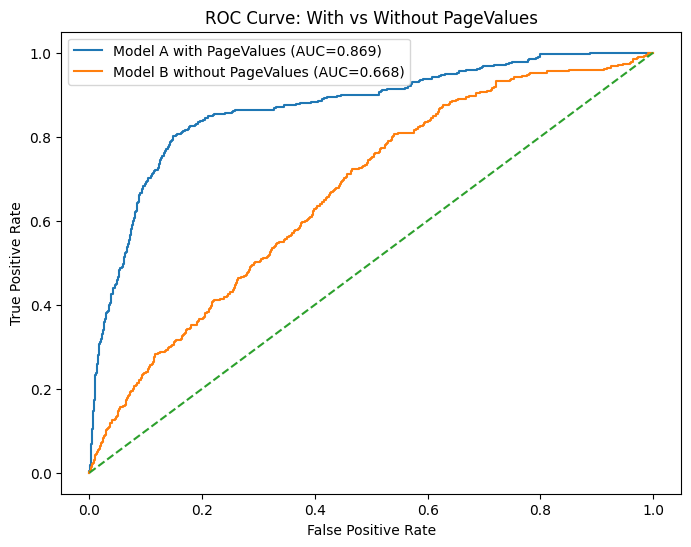

In [100]:
#再画一张 ROC Curve

import matplotlib.pyplot as plt

from sklearn.metrics import roc_curve

fpr_A, tpr_A, _ = roc_curve(y_test, y_prob_A)
fpr_B, tpr_B, _ = roc_curve(y_test, y_prob_B)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_A,
    tpr_A,
    label=f"Model A with PageValues (AUC={auc_A:.3f})"
)

plt.plot(
    fpr_B,
    tpr_B,
    label=f"Model B without PageValues (AUC={auc_B:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: With vs Without PageValues")

plt.legend()

plt.savefig(
    "../images/roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [101]:
#第二个模型：Random Forest
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train
)

rf_prob = rf_model.predict_proba(
    X_test
)[:, 1]

rf_pred = rf_model.predict(
    X_test
)

In [102]:
#评估
print(
    classification_report(
        y_test,
        rf_pred
    )
)

print(
    "ROC-AUC:",
    roc_auc_score(
        y_test,
        rf_prob
    )
)

              precision    recall  f1-score   support

           0       0.92      0.97      0.94      2084
           1       0.73      0.52      0.61       382

    accuracy                           0.90      2466
   macro avg       0.82      0.74      0.77      2466
weighted avg       0.89      0.90      0.89      2466

ROC-AUC: 0.8887503642813356


In [103]:
#Feature Importance
feature_importance = pd.DataFrame({
    "feature": features,
    "importance": rf_model.feature_importances_
}).sort_values(
    "importance",
    ascending=False
)

feature_importance

,feature,importance
8,PageValues,0.428823
7,ExitRates,0.125333
5,ProductRelated_Duration,0.124438
4,ProductRelated,0.086943
6,BounceRates,0.070360
1,Administrative_Duration,0.067771
0,Administrative,0.041570
3,Informational_Duration,0.028200
2,Informational,0.017164
9,SpecialDay,0.009397


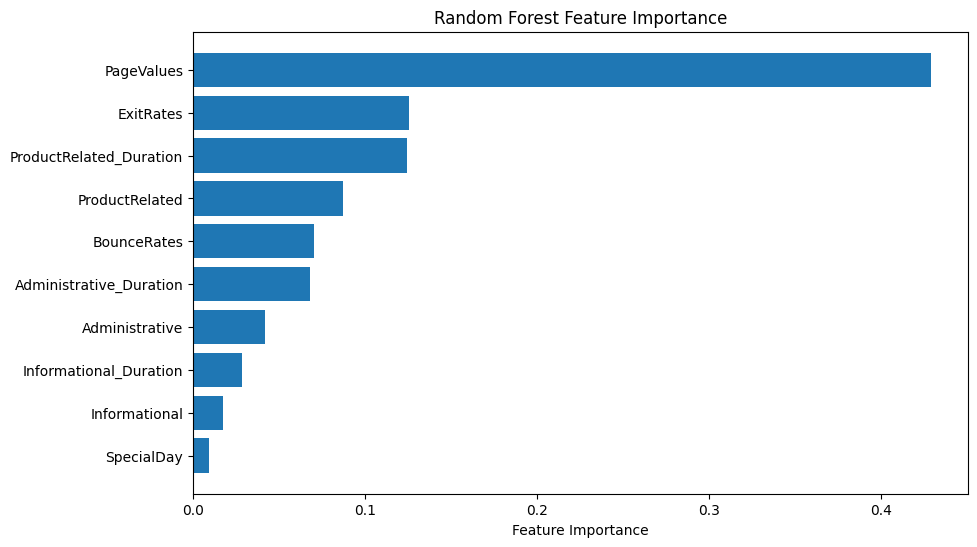

In [105]:
#画图
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["feature"],
    feature_importance["importance"]
)

plt.xlabel("Feature Importance")
plt.title(
    "Random Forest Feature Importance"
)

plt.gca().invert_yaxis()

plt.savefig(
    "../images/feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [106]:
#生成购买概率，业务评分字段
df_model = df.copy()

df_model["purchase_probability"] = (
    logistic_model.predict_proba(
        df[features]
    )[:, 1]
)

In [107]:
#建立预测型高潜Session
model_high_potential = df_model[
    (df_model["purchase_probability"] >= 0.7)
    & (df_model["Revenue"] == False)
].copy()

In [108]:
# 先不要进行0.7，先看看
df_model[
    "purchase_probability"
].describe(
    percentiles=[
        0.5,
        0.75,
        0.9,
        0.95
    ]
)

count    12330.000000
mean         0.347065
std          0.263930
min          0.003702
50%          0.281559
75%          0.400688
90%          0.833762
95%          0.977795
max          1.000000
Name: purchase_probability, dtype: float64

In [109]:
#定义top 10% 的高潜用户
prob_p90 = df_model[
    "purchase_probability"
].quantile(0.90)

print("P90 threshold:", prob_p90)

model_high_potential = df_model[
    (df_model["purchase_probability"] >= prob_p90)
    & (df_model["Revenue"] == False)
].copy()

print(
    "Model high potential sessions:",
    len(model_high_potential)
)

P90 threshold: 0.833762399718408
Model high potential sessions: 356


In [110]:
#
print("规则法高潜数量：", len(rule_ids))
print("模型法高潜数量：", len(model_ids))
print("重合数量：", len(overlap))

print(
    "规则法被模型覆盖率：",
    len(overlap) / len(rule_ids)
)

print(
    "模型法被规则覆盖率：",
    len(overlap) / len(model_ids)
)

print(
    "Jaccard：",
    len(overlap) / len(rule_ids | model_ids)
)

规则法高潜数量： 2376
模型法高潜数量： 356
重合数量： 188
规则法被模型覆盖率： 0.07912457912457913
模型法被规则覆盖率： 0.5280898876404494
Jaccard： 0.07389937106918239


In [111]:
#最后比较两类高潜Session
rule_ids = set(
    high_potential_p75.index
)

model_ids = set(
    model_high_potential.index
)

overlap = (
    rule_ids
    &
    model_ids
)

len(overlap)

188

In [112]:
#回答模型找到的人，和简单规则找到的人重合度有多高
len(overlap) / len(rule_ids)

0.07912457912457913

In [113]:

rule_only_ids = rule_ids - model_ids
model_only_ids = model_ids - rule_ids
both_ids = rule_ids & model_ids

print("Rule Only:", len(rule_only_ids))
print("Model Only:", len(model_only_ids))
print("Both:", len(both_ids))

Rule Only: 2188
Model Only: 168
Both: 188


In [114]:
rule_only = df_model.loc[list(rule_only_ids)]
model_only = df_model.loc[list(model_only_ids)]
both = df_model.loc[list(both_ids)]

In [115]:
compare_groups = pd.DataFrame({
    "Rule Only": [
        rule_only["ProductRelated"].mean(),
        rule_only["ProductRelated_Duration"].mean(),
        rule_only["BounceRates"].mean(),
        rule_only["ExitRates"].mean(),
        rule_only["PageValues"].mean(),
        rule_only["purchase_probability"].mean()
    ],

    "Model Only": [
        model_only["ProductRelated"].mean(),
        model_only["ProductRelated_Duration"].mean(),
        model_only["BounceRates"].mean(),
        model_only["ExitRates"].mean(),
        model_only["PageValues"].mean(),
        model_only["purchase_probability"].mean()
    ],

    "Both": [
        both["ProductRelated"].mean(),
        both["ProductRelated_Duration"].mean(),
        both["BounceRates"].mean(),
        both["ExitRates"].mean(),
        both["PageValues"].mean(),
        both["purchase_probability"].mean()
    ]
}, index=[
    "ProductRelated",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates",
    "PageValues",
    "PurchaseProbability"
])

compare_groups

,Rule Only,Model Only,Both
ProductRelated,76.574040,23.339286,130.797872
ProductRelated_Duration,2739.787629,1075.106445,5294.928476
BounceRates,0.007928,0.008149,0.003961
ExitRates,0.022398,0.022218,0.015017
PageValues,1.701156,43.220762,33.066957
PurchaseProbability,0.410801,0.946344,0.934742


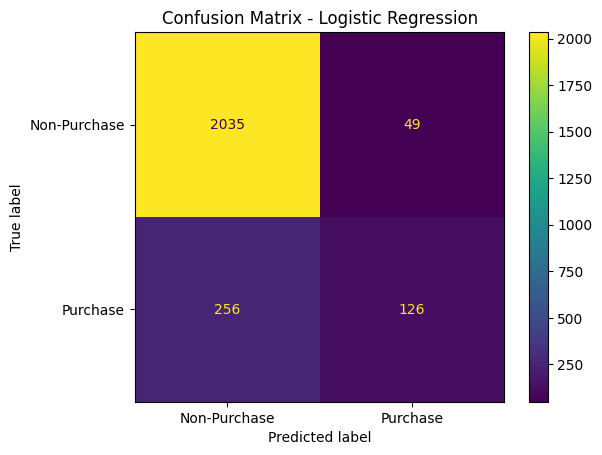

In [117]:
#做 Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_A)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-Purchase", "Purchase"]
)

disp.plot()

plt.title("Confusion Matrix - Logistic Regression")

plt.savefig(
    "../images/confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

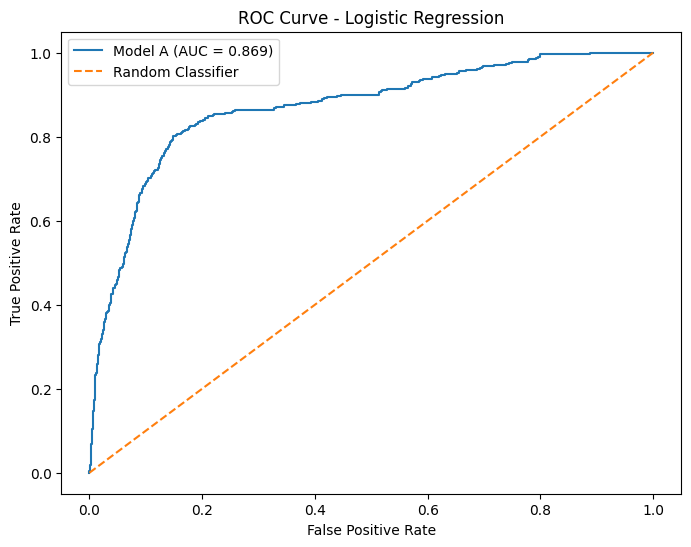

In [119]:
#画ROC Curve
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob_A
)

auc = roc_auc_score(
    y_test,
    y_prob_A
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Model A (AUC = {auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()

plt.savefig(
    "../images/roc_curve_logistic_regression.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [120]:
#更重要的Threshold Tuning
#测试几个简单阈值
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

threshold_results = []

for threshold in [
    0.2,
    0.3,
    0.4,
    0.5,
    0.6,
    0.7
]:
    
    y_pred_threshold = (
        y_prob_A >= threshold
    ).astype(int)
    
    precision = precision_score(
        y_test,
        y_pred_threshold
    )
    
    recall = recall_score(
        y_test,
        y_pred_threshold
    )
    
    f1 = f1_score(
        y_test,
        y_pred_threshold
    )
    
    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    })


threshold_df = pd.DataFrame(
    threshold_results
)

threshold_df

,Threshold,Precision,Recall,F1
0,0.2,0.582500,0.609948,0.595908
1,0.3,0.620690,0.471204,0.535714
2,0.4,0.672646,0.392670,0.495868
3,0.5,0.720000,0.329843,0.452424
4,0.6,0.764286,0.280105,0.409962
5,0.7,0.777778,0.238220,0.364729


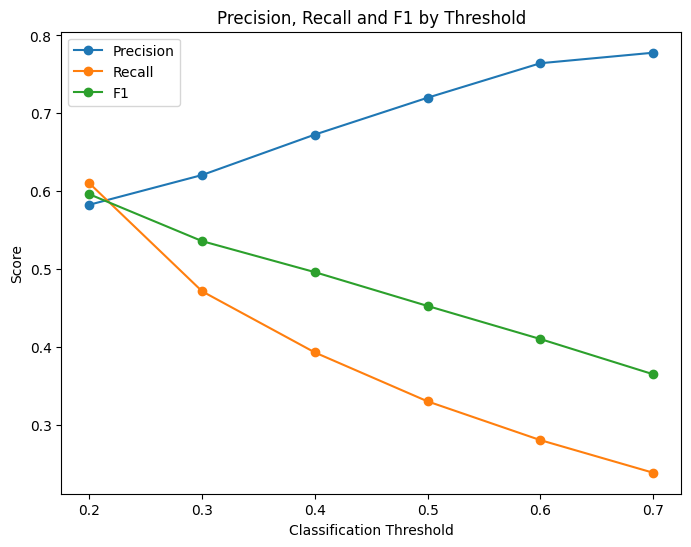

In [122]:
plt.figure(figsize=(8, 6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1"],
    marker="o",
    label="F1"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title(
    "Precision, Recall and F1 by Threshold"
)

plt.legend()

plt.savefig(
    "../images/precision_recall_f1.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()